In [241]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.utils.class_weight import compute_sample_weight

In [242]:
# prepare data 
cols = ["fixed acidity","volatile acidity","citric acid","residual sugar",
        "chlorides","free sulfur dioxide","total sulfur dioxide","density",
        "pH","sulphates","alcohol","quality"]
df = pd.read_csv("winequality-red-1.csv",
                 sep=";", skiprows=1, header=None, names=cols)
print("Shape:", df.shape)
print("\nQuality distribution:\n", df["quality"].value_counts().sort_index())

X = df.drop("quality", axis=1)
y = df["quality"]
feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)  # fit only on train!

Shape: (1599, 12)

Quality distribution:
 quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


We can see that class 5 and 6 dominate the dataset, and that class 3,4, 8 have significantly fewer samples.

In [243]:

ann = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),  # 3 hidden layers
    activation='relu',                  # ReLU is standard
    solver='adam',                      # adaptive learning rate
    alpha=0.001,                        # L2 regularization
    batch_size=32,
    learning_rate_init=0.001,
    max_iter=500,
    early_stopping=True,                # prevents overfitting
    validation_fraction=0.1,
    random_state=42
)

ann.fit(X_train, y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(128, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",32
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",500
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


In [244]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score

# Pipeline ensures scaler is fit only on training folds (no leakage)
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('ann', MLPClassifier(solver='adam', max_iter=500, early_stopping=True, random_state=42))
])

param_grid = {
    'ann__hidden_layer_sizes': [(64, 32), (128, 64), (128, 64, 32), (256, 128, 64)],
    'ann__alpha': [0.0001, 0.001, 0.01],
    'ann__learning_rate_init': [0.0001, 0.001, 0.01],
    'ann__activation': ['relu', 'tanh'],
    'ann__batch_size': [32, 64],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# GridSearchCV already does 5-fold CV — no need for separate cross_val_score
grid = GridSearchCV(pipe, param_grid, cv=cv, scoring='accuracy', n_jobs=-1)

# Use original unscaled X_train here since pipeline handles scaling
X_train_raw, _, y_train_raw, _ = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
grid.fit(X_train_raw, y_train_raw)

print("Best params:", grid.best_params_)
print(f"Best CV Accuracy: {grid.best_score_:.4f}")

Best params: {'ann__activation': 'relu', 'ann__alpha': 0.0001, 'ann__batch_size': 32, 'ann__hidden_layer_sizes': (256, 128, 64), 'ann__learning_rate_init': 0.001}
Best CV Accuracy: 0.6177


In [245]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred = ann.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.615625
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.64      0.76      0.70       136
           6       0.58      0.62      0.60       128
           7       0.64      0.35      0.45        40
           8       0.00      0.00      0.00         3

    accuracy                           0.62       320
   macro avg       0.31      0.29      0.29       320
weighted avg       0.59      0.62      0.59       320



/Users/soniapalamand/Documents/ESE417_finalproj/.conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/soniapalamand/Documents/ESE417_finalproj/.conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/soniapalamand/Documents/ESE417_finalproj/.conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to contr

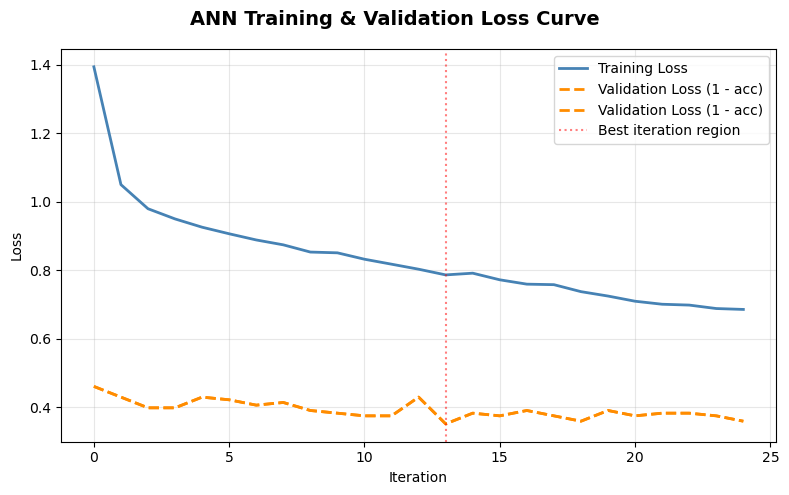

In [246]:
fig, ax = plt.subplots(figsize=(8, 5))
fig.suptitle('ANN Training & Validation Loss Curve', fontsize=14, fontweight='bold')

ax.plot(ann.loss_curve_, label='Training Loss', color='steelblue', linewidth=2)
if ann.validation_scores_ is not None:
    # validation_scores_ is accuracy; invert for "loss" proxy
    val_loss = [1 - s for s in ann.validation_scores_]
    ax.plot(val_loss, label='Validation Loss (1 - acc)', color='darkorange',
            linewidth=2, linestyle='--')


if ann.validation_scores_ is not None:
    val_loss = [1 - s for s in ann.validation_scores_]
    ax.plot(val_loss, label='Validation Loss (1 - acc)', color='darkorange',
            linewidth=2, linestyle='--')
    best_iter = ann.validation_scores_.index(max(ann.validation_scores_))
    ax.axvline(x=best_iter, color='red', linestyle=':', alpha=0.5, label='Best iteration region')


# ax.axvline(x=ann.best_loss_, color='red', linestyle=':', alpha=0.5, label='Best iteration region')
ax.set_xlabel('Iteration')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plot5_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

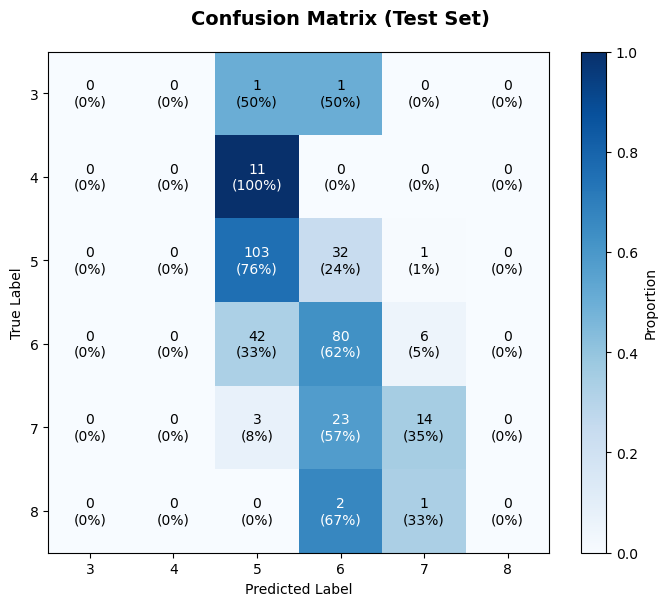

In [247]:

fig, ax = plt.subplots(figsize=(7, 6))
fig.suptitle('Confusion Matrix (Test Set)', fontsize=14, fontweight='bold')

cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='Proportion')

class_labels = sorted(y_test.unique())  # get actual class labels
n = len(class_labels)
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(class_labels)
ax.set_yticklabels(class_labels)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')

for i in range(n):
    for j in range(n):
        ax.text(j, i, f'{cm[i,j]}\n({cm_norm[i,j]:.0%})',
                ha='center', va='center', fontsize=10,
                color='white' if cm_norm[i, j] > 0.5 else 'black')

plt.tight_layout()
plt.savefig('plot6_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

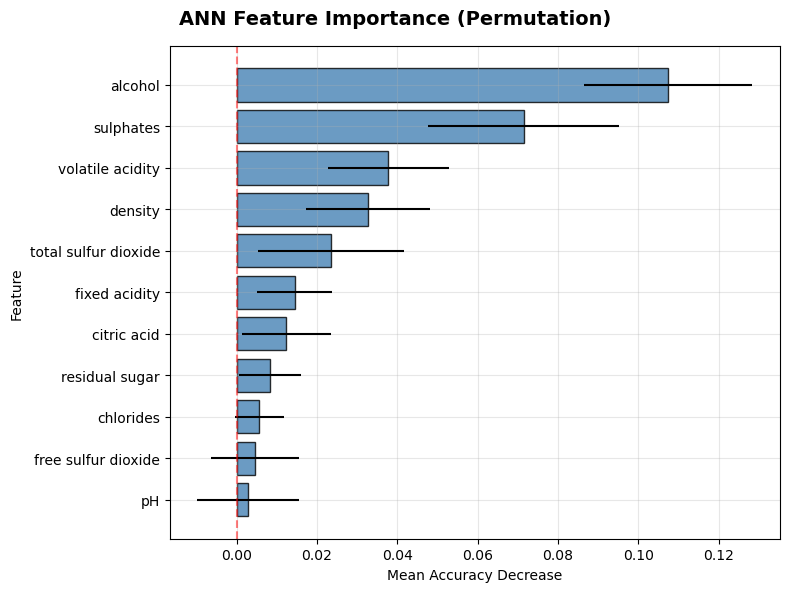

In [248]:
from sklearn.inspection import permutation_importance

# Compute permutation importance on test set
perm = permutation_importance(ann, X_test, y_test, n_repeats=30, random_state=42, n_jobs=-1)

# Sort by importance
sorted_idx = perm.importances_mean.argsort()

fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle('ANN Feature Importance (Permutation)', fontsize=14, fontweight='bold')

ax.barh(
    [feature_names[i] for i in sorted_idx],
    perm.importances_mean[sorted_idx],
    xerr=perm.importances_std[sorted_idx],
    color='steelblue',
    edgecolor='black',
    alpha=0.8
)

ax.set_xlabel('Mean Accuracy Decrease')
ax.set_ylabel('Feature')
ax.axvline(x=0, color='red', linestyle='--', alpha=0.5)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plot_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

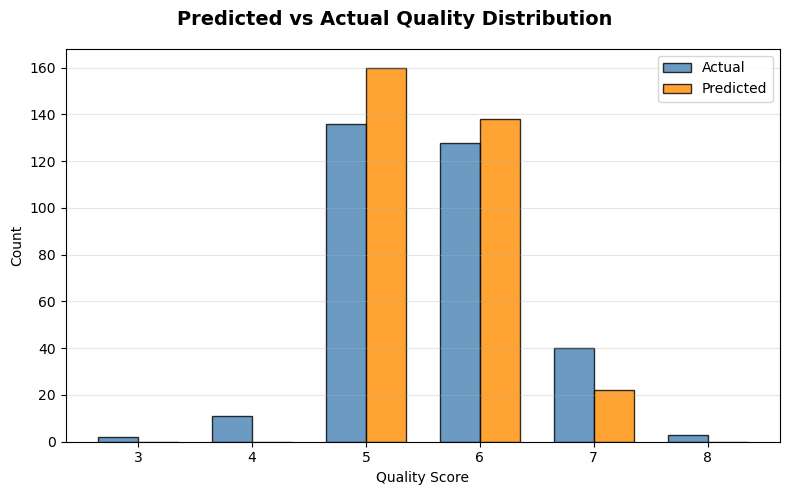

In [249]:
fig, ax = plt.subplots(figsize=(8, 5))
fig.suptitle('Predicted vs Actual Quality Distribution', fontsize=14, fontweight='bold')

class_labels = sorted(y_test.unique())
x = np.arange(len(class_labels))
width = 0.35

actual_counts = [sum(y_test == c) for c in class_labels]
pred_counts = [sum(y_pred == c) for c in class_labels]

ax.bar(x - width/2, actual_counts, width, label='Actual', color='steelblue', edgecolor='black', alpha=0.8)
ax.bar(x + width/2, pred_counts, width, label='Predicted', color='darkorange', edgecolor='black', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(class_labels)
ax.set_xlabel('Quality Score')
ax.set_ylabel('Count')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('plot_pred_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

/Users/soniapalamand/Documents/ESE417_finalproj/.conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/soniapalamand/Documents/ESE417_finalproj/.conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/soniapalamand/Documents/ESE417_finalproj/.conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to contr

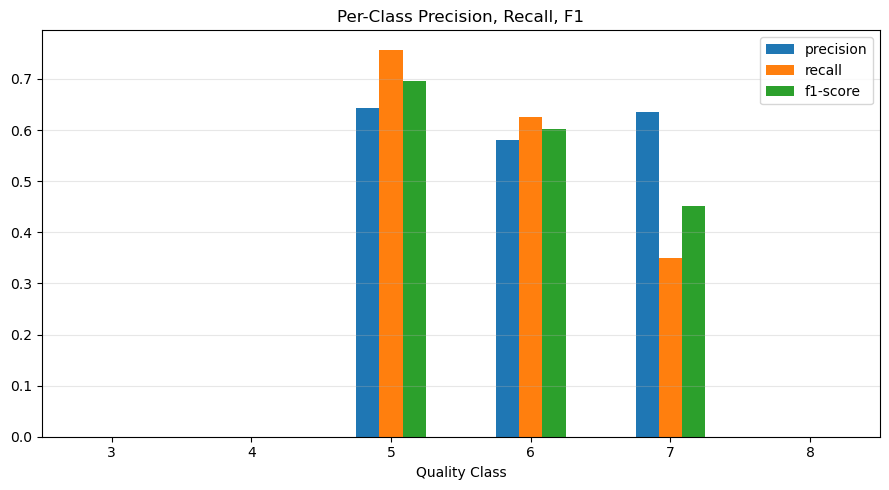

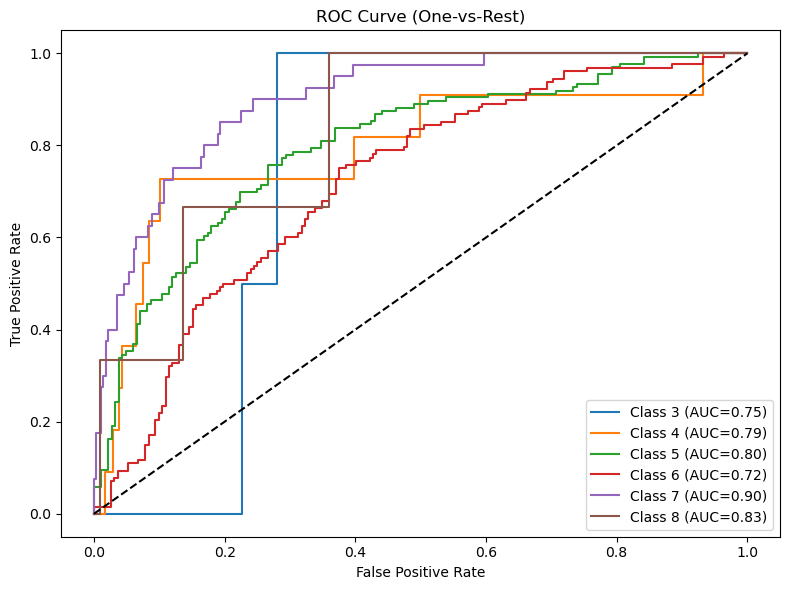

In [250]:
from sklearn.metrics import classification_report
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).T.drop(['accuracy', 'macro avg', 'weighted avg'])

report_df[['precision', 'recall', 'f1-score']].plot(kind='bar', figsize=(9, 5))
plt.title('Per-Class Precision, Recall, F1')
plt.xlabel('Quality Class')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

classes = sorted(y.unique())
y_test_bin = label_binarize(y_test, classes=classes)
y_prob = ann.predict_proba(X_test)

fig, ax = plt.subplots(figsize=(8, 6))
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    ax.plot(fpr, tpr, label=f'Class {cls} (AUC={auc(fpr,tpr):.2f})')

ax.plot([0,1],[0,1],'k--')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve (One-vs-Rest)')
ax.legend()
plt.tight_layout()
plt.show()

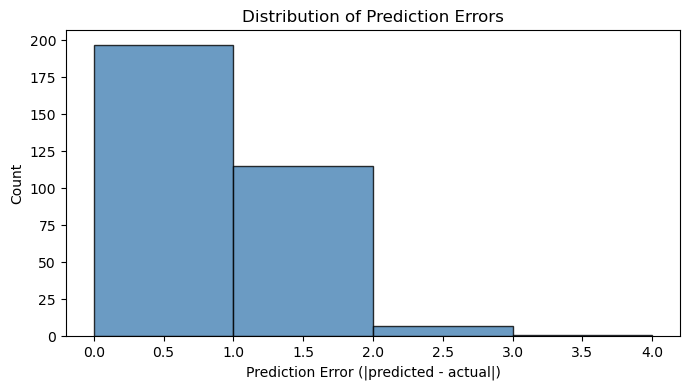

In [251]:
errors = np.abs(y_pred - y_test)
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(errors, bins=range(0, int(errors.max())+2), color='steelblue', edgecolor='black', alpha=0.8)
ax.set_xlabel('Prediction Error (|predicted - actual|)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Prediction Errors')
plt.tight_layout()
plt.show()

        total  correct  mean_error  error_rate
actual                                        
3           2        0    2.500000    1.000000
4          11        0    1.000000    1.000000
5         136      103    0.250000    0.242647
6         128       80    0.375000    0.375000
7          40       14    0.725000    0.650000
8           3        0    1.666667    1.000000


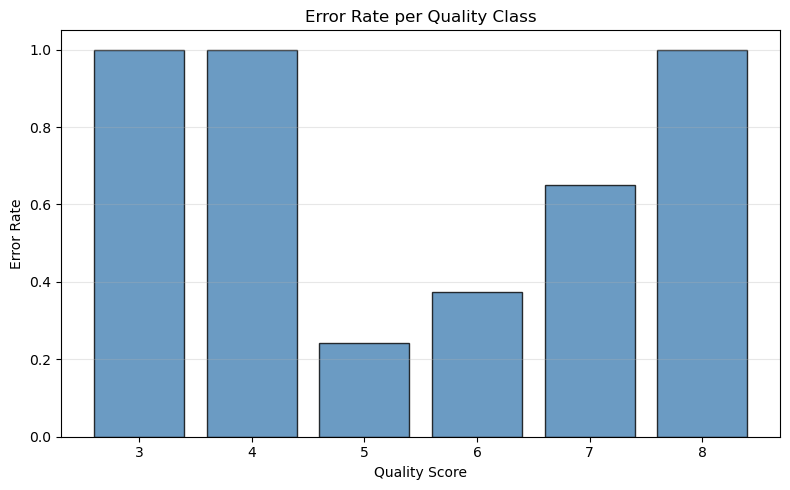

In [252]:
import pandas as pd

# Create a results dataframe
results_df = pd.DataFrame({'actual': y_test.values, 'predicted': y_pred})
results_df['error'] = np.abs(results_df['actual'] - results_df['predicted'])
results_df['correct'] = results_df['actual'] == results_df['predicted']

# Error rate per class
error_by_class = results_df.groupby('actual').agg(
    total=('correct', 'count'),
    correct=('correct', 'sum'),
    mean_error=('error', 'mean')
)
error_by_class['error_rate'] = 1 - error_by_class['correct'] / error_by_class['total']
print(error_by_class)

# Plot error rate per class
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(error_by_class.index, error_by_class['error_rate'], 
       color='steelblue', edgecolor='black', alpha=0.8)
ax.set_xlabel('Quality Score')
ax.set_ylabel('Error Rate')
ax.set_title('Error Rate per Quality Class')
ax.set_xticks(error_by_class.index)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()